# 添加详尽中文注释的代码
以下代码包含了一个完整的优化流程，包括数据生成、局部搜索、增强选择以及最终的结果分析。每个部分都将添加详尽的中文注释，以便更好地理解代码的功能和逻辑。

# 选择模型

## 训练曲线展示

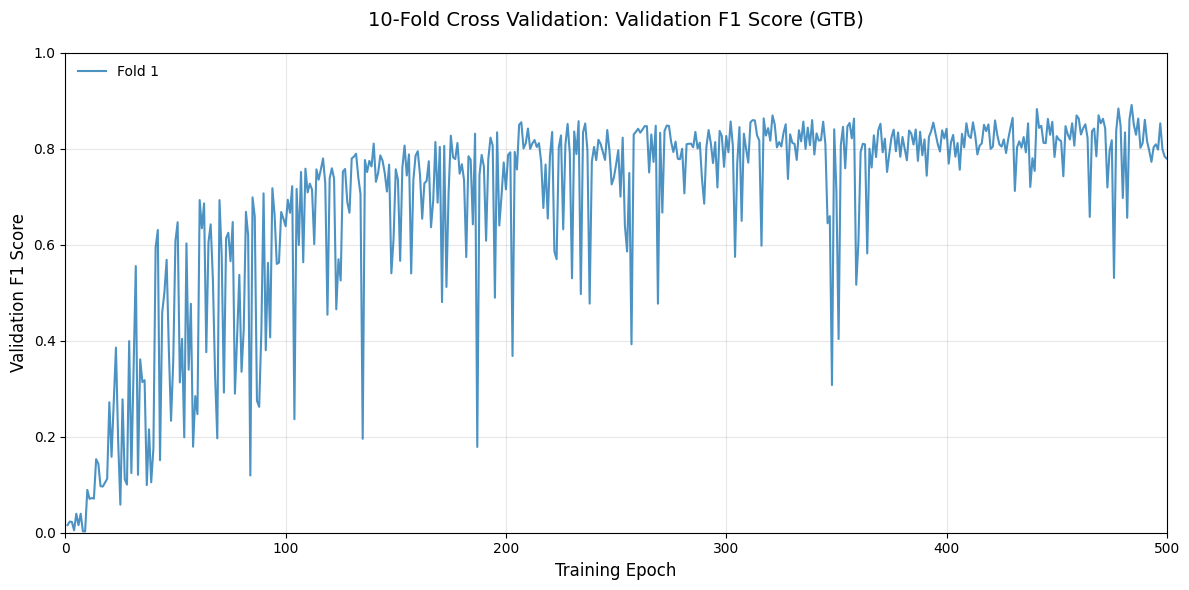

In [11]:
import os
import pandas as pd

data_path = "./model_param_alldata/"
base_name = "GTmining_6_6_GTB_fold"

validation_data = []
for fold in range(1, 11):
    folder_name = f"{base_name}{fold}"
    tsv_filename = os.path.join(data_path, folder_name, 'validation_log.csv')
    df = pd.read_csv(tsv_filename)
    validation_data.append(df['validation_f1_score'].to_list())

import matplotlib.pyplot as plt
import numpy as np

# ===================== 1. 替换为你的真实数据 =====================
# 示例：10个嵌套列表，每个子列表是某一折的validation_f1_score（长度为训练轮次）
# 你需将下面的示例数据替换成自己的10折F1分数列表
val_f1_scores = validation_data

# ===================== 2. 配置绘图样式（10种不同颜色+线型+标记） =====================
# 10种区分度高的颜色（matplotlib tab10配色，适配10折）
colors = plt.cm.tab10(np.linspace(0, 1, 10))
# 10种不同线型（确保视觉区分）
linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--']
# 10种不同标记（增强区分度）
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', '+', 'x']

# ===================== 3. 绘制折线图 =====================
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # 解决中文显示（无中文可删）
plt.figure(figsize=(12, 6))  # 画布大小：宽12，高6

# 循环绘制每折的F1分数折线
for fold_idx in range(0, 1):
    # 获取当前折的F1分数
    f1 = val_f1_scores[fold_idx]
    # 训练轮次（x轴，长度与F1分数一致）
    epochs = range(1, len(f1) + 1)
    
    # 绘制折线：颜色+线型+标记+标签
    plt.plot(
        epochs, f1,
        color=colors[fold_idx],
        linestyle=linestyles[fold_idx],
        # marker=markers[fold_idx],
        label=f'Fold {fold_idx + 1}',  # 图例标签：Fold 1 ~ Fold 10
        linewidth=1.5,  # 线条宽度
        alpha=0.8,
        # markersize=6    # 标记大小
    )

# ===================== 4. 图表美化与标注 =====================
# plt.title('10-Fold Cross Validation: Validation F1 Score (GTA)', fontsize=14, pad=20)
plt.title('10-Fold Cross Validation: Validation F1 Score (GTB)', fontsize=14, pad=20)
plt.xlabel('Training Epoch', fontsize=12)
plt.ylabel('Validation F1 Score', fontsize=12)
plt.ylim(0, 1)  # y轴范围
plt.xlim(0, 500)  # x轴范围
# plt.ylim(0, 0.8)  # y轴范围
# plt.xlim(0, 1000)  # x轴范围
plt.grid(True, alpha=0.3)  # 网格线（增强可读性）
plt.legend(loc='upper left', ncol=2, edgecolor='white')  # 图例：右下位置，2列展示（避免拥挤）
plt.tight_layout()  # 自动调整布局（防止标签重叠）

# ===================== 5. 保存/显示图表 =====================
# plt.savefig('./result/10fold_val_f1_score_GTB.png', dpi=1200, bbox_inches='tight')  # 保存为高清PNG
# plt.savefig('./result/10fold_val_f1_score_GTB.svg', bbox_inches='tight')  # 保存为SVG
plt.show()  # 显示图表


## 模型epoch逐条预测

### 拿validation数据，选取前十的epoch

In [4]:
import os
import pandas as pd

best_20_epochs = {}
fold_type = 'GTA'
family_fold_type = fold_type
log_save_folder = f'GTmining_6_6_{fold_type}_fold'

for fold in range(1, 11):
    log_dir = f'./model_param_alldata/{log_save_folder}{fold}/validation_log.csv'
    df = pd.read_csv(log_dir, index_col=False)
    df.sort_values(by='validation_f1_score', ascending=False, inplace=True)
    df.reset_index(drop=True, inplace=True)

    epochs_20 = df.loc[0:19, 'epoch'].values.tolist()
    best_20_epochs[fold] = epochs_20
    print(f"Fold type {fold_type}, Fold: {fold}, Top 20 Epochs: {epochs_20}")


Fold type GTA, Fold: 1, Top 20 Epochs: [672, 698, 723, 931, 883, 638, 940, 925, 600, 718, 839, 834, 885, 853, 970, 508, 917, 816, 868, 928]
Fold type GTA, Fold: 2, Top 20 Epochs: [820, 883, 764, 822, 994, 851, 733, 746, 770, 732, 699, 972, 752, 782, 966, 868, 801, 876, 997, 795]
Fold type GTA, Fold: 3, Top 20 Epochs: [974, 973, 879, 849, 838, 996, 930, 893, 850, 884, 929, 863, 854, 825, 871, 933, 960, 891, 631, 875]
Fold type GTA, Fold: 4, Top 20 Epochs: [570, 895, 999, 754, 728, 690, 940, 814, 794, 804, 964, 741, 942, 929, 777, 909, 904, 778, 914, 632]
Fold type GTA, Fold: 5, Top 20 Epochs: [721, 788, 717, 910, 451, 494, 791, 437, 787, 388, 573, 392, 907, 946, 633, 620, 840, 601, 969, 570]
Fold type GTA, Fold: 6, Top 20 Epochs: [823, 950, 951, 947, 915, 949, 948, 706, 825, 953, 786, 833, 965, 824, 909, 918, 912, 957, 954, 961]
Fold type GTA, Fold: 7, Top 20 Epochs: [964, 885, 929, 975, 915, 862, 965, 953, 978, 875, 930, 982, 908, 934, 704, 922, 903, 824, 935, 983]
Fold type GTA, Fold:

### 评估validation数据集中的数据标签，并临时保存下来

In [5]:
import argparse
import textwrap
import os
import time
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.data import tu
from model.encoder import DiffPool
from livelossplot import PlotLosses
from sklearn.metrics import f1_score
import shutil
import pandas as pd

import os
import pandas as pd

In [6]:
def prepare_data(dataset, shuffle=False, prog_args=None):
    """
    preprocess TU dataset according to DiffPool's paper setting and load dataset into dataloader
    """
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )

def prepare_data_one(dataset, shuffle=False, prog_args=None):
    """
    preprocess TU dataset according to DiffPool's paper setting and load dataset into dataloader
    """
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=1,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )




In [7]:
fold_num = 1


# ========================================
data_path = "./model_param_alldata/"
base_name = f"GTmining_6_6_{family_fold_type}_fold"
folder_name = f"{base_name}{fold_num}"
# ========================================

print("{:=^100}".format(f'fold num is : {fold_num}, family type is : {family_fold_type}'))

print("{:=^100}".format('prog_args'))
prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                               batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                               dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                               load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)
print(textwrap.fill(str(prog_args), width=100))

print("{:=^100}".format('加载数据'))
dataset_train = tu.LegacyTUDataset(name="GTmining",
                                    raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/train/')
dataset_validation = tu.LegacyTUDataset(name="GTmining",
                                   raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/')
dataset_test = tu.LegacyTUDataset(name="GTmining",
                                   raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/test/')
train_dataloader = prepare_data(dataset_train, shuffle=True, prog_args=prog_args)
validation_dataloader = prepare_data_one(dataset_validation, shuffle=False, prog_args=prog_args)
test_dataloader = prepare_data_one(dataset_test, shuffle=False, prog_args=prog_args)

input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
input_dim_validation, label_dim_validation, max_num_node_validation = dataset_validation.statistics()
input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
max_num_node = max([max_num_node_train, max_num_node_validation, max_num_node_test])
input_dim = input_dim_train
label_dim = label_dim_train
print("++++++++++ STATISTICS ABOUT THE DATASET ++++++++++")
print("dataset feature dimension is", input_dim_train)
print("dataset label dimension is", label_dim_train)
print("the max num node is", max_num_node)
print("number of graphs is", len(dataset_train) + len(dataset_validation)+ len(dataset_test))

hidden_dim = prog_args.hidden_dim  # used to be 64
embedding_dim = prog_args.embedding_dim

assign_dim = int(max_num_node * prog_args.pool_ratio)
print("++++++++++MODEL STATISTICS++++++++")
print("model hidden dim is", hidden_dim)
print("model embedding dim for graph instance embedding", embedding_dim)
print("initial batched pool graph dim is", assign_dim)
activation = F.relu

if family_fold_type == 'GTA':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6,
                        'dTDP-Rha': 7, 'Other': 8}
elif family_fold_type == 'GTB':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                        'dTDP-Rha': 8, 'Other': 9}
else:
    raise ValueError(f"Invalid family_fold_type: '{prog_args.family_fold_type}'. Valid options are 'GTA' and 'GTB'.")

df_cluster = pd.read_excel(f'../data/cluster/{family_fold_type}/dataseat_split_{fold_num}.xlsx')
df_cluster = df_cluster.loc[df_cluster['Dataset']=='train']
df_cluster.reset_index(drop=True, inplace=True)
custom_loss_weight = []
total_sample = df_cluster.shape[0]
for x in graph_label_dict.keys():
    df_x = df_cluster.loc[df_cluster['Activate']==x]
    df_x.reset_index(drop=True, inplace=True)
    x_sample = df_x.shape[0]
    custom_loss_weight.append(total_sample/x_sample)

assert len(custom_loss_weight) == label_dim_train, 'Wrong custom loss weight, please check what happen.'


===============================fold num is : 1, family type is : GTA================================
=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTA_fold1', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type='GTA')
================================================加载数据================================================
++++++++++ STATISTICS ABOUT THE DATASET ++++++++++
dataset feature dimension is 7
dataset label dimension is 9
the max num node is 537
number of graphs is 11489
++++++++++MODEL STATISTICS++++++++
model hidden dim is 64
model embedding dim for graph instance embedding 64
initial batched pool graph dim is 53


In [8]:
# initialize model
model = DiffPool(
    input_dim,
    hidden_dim,
    embedding_dim,
    label_dim,
    activation,
    prog_args.gc_per_block,
    prog_args.dropout,
    prog_args.num_pool,
    prog_args.linkpred,
    prog_args.batch_size,
    prog_args.aggregator_type,
    assign_dim,
    prog_args.pool_ratio,
    custom_loss_weight
)
print("model init finished")
print("MODEL:::::::", prog_args.method)
if prog_args.cuda:
    model = model.cuda()

# 先过一遍train_dataloader，让模型中的一些参数先初始化一下
model.train()
for batch_idx, (batch_graph, graph_labels) in enumerate(train_dataloader):
    for key, value in batch_graph.ndata.items():
        batch_graph.ndata[key] = value.float()
    graph_labels = graph_labels.long()
    if torch.cuda.is_available():
        batch_graph = batch_graph.to(torch.cuda.current_device())
        graph_labels = graph_labels.cuda()
    ypred = model(batch_graph)
    loss = model.loss(ypred, graph_labels)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=prog_args.clip)
    model.zero_grad()



model init finished
MODEL::::::: diffpool


In [7]:
print("Fold_num is {}{:=^100}".format(fold_num, '开始选择最佳epoch进行验证'))
for top_i in range(0, 20):
    epoch = best_20_epochs[fold_num][top_i]

    begin_time = time.time()
    print("\nEPOCH ###### {} ######".format(epoch))
    if epoch is not None and prog_args.save_dir is not None:
        model.load_state_dict(
            torch.load(
                prog_args.save_dir
                + "/"
                + prog_args.dataset
                + "/model.iter-"
                + "{:04d}".format(epoch), weights_only=True
            )
        )

    id_card_protein = {}
    # validation test
    with open(f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/Predict_correspond_information.txt', 'r')as f:
        for dd in f.readlines():
            dd = dd.split('\n')[0].split('===')
            id_card_protein[dd[1]] = dd[0]

    id_card_record_list = []
    real_label_record_list = []
    predict_label_record_list = []
    graph_label_dict_reverse = {v: k for k, v in graph_label_dict.items()}

    model.eval()
    correct_label = 0
    with torch.no_grad():
        val_pred_indi = torch.tensor([], device='cuda')
        val_label_indi = torch.tensor([], device='cuda')
        for batch_idx, (batch_graph, graph_labels) in enumerate(validation_dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()

            # 拿标签
            temp = batch_graph
            protein_temp_id_card = ''
            protein_temp_id_card = protein_temp_id_card + "{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}".format(round(float(temp.ndata['feat'][0][0]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][0][1]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][0][2]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][0][3]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][0][4]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][0][5]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][0][6]), 5))
            protein_temp_id_card = protein_temp_id_card + "###{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}".format(round(float(temp.ndata['feat'][1][0]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][1][1]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][1][2]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][1][3]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][1][4]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][1][5]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][1][6]), 5))
            protein_temp_id_card = protein_temp_id_card + "###{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}".format(round(float(temp.ndata['feat'][2][0]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][2][1]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][2][2]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][2][3]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][2][4]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][2][5]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][2][6]), 5))
            protein_id = id_card_protein[protein_temp_id_card]

            ypred = model(batch_graph)
            indi = torch.argmax(ypred, dim=1)

            # 记录id_card_record_list，real_label_record_list，predict_label_record_list
            id_card_record_list.append(protein_id)
            real_label_record_list.append(graph_label_dict_reverse[int(graph_labels.cpu())])
            predict_label_record_list.append(graph_label_dict_reverse[int(indi.cpu())])

            val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
            val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
            correct = torch.sum(indi == graph_labels)
            correct_label += correct.item()

            # print(f"Protein name is : {protein_id}, and its activate is {int(indi.cpu())}.")
            
    elapsed_time = time.time() - begin_time
    print("epoch {:.4f} with epoch time {:.4f} s".format(epoch, elapsed_time))
    result = correct_label / len(validation_dataloader.dataset)

    # 记录预测的label数据文件
    storage_label_file = prog_args.save_dir + "/" + prog_args.dataset + f"/validation_pred_labels_epoch_{epoch}_top{top_i}.csv"

    with open(storage_label_file, 'w') as f:
        f.write("ID_Card,Real_Label,Predict_Label\n")
        for id_card, real_label, predict_label in zip(id_card_record_list, real_label_record_list, predict_label_record_list):
            f.write(f"{id_card},{real_label},{predict_label}\n")
    f.close()
    


Fold_num is 2==========================================开始选择最佳epoch进行验证===========================================

EPOCH ###### 820 ######


/home/admin123/software/miniconda3/envs/GTmining_env/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


epoch 820.0000 with epoch time 68.2437 s

EPOCH ###### 883 ######
epoch 883.0000 with epoch time 67.9794 s

EPOCH ###### 764 ######
epoch 764.0000 with epoch time 68.1338 s

EPOCH ###### 822 ######
epoch 822.0000 with epoch time 67.9739 s

EPOCH ###### 994 ######
epoch 994.0000 with epoch time 68.4180 s

EPOCH ###### 851 ######
epoch 851.0000 with epoch time 67.9992 s

EPOCH ###### 733 ######
epoch 733.0000 with epoch time 68.3600 s

EPOCH ###### 746 ######
epoch 746.0000 with epoch time 68.7898 s

EPOCH ###### 770 ######
epoch 770.0000 with epoch time 68.2058 s

EPOCH ###### 732 ######
epoch 732.0000 with epoch time 68.1694 s

EPOCH ###### 699 ######
epoch 699.0000 with epoch time 69.7996 s

EPOCH ###### 972 ######
epoch 972.0000 with epoch time 69.0332 s

EPOCH ###### 752 ######
epoch 752.0000 with epoch time 68.5955 s

EPOCH ###### 782 ######
epoch 782.0000 with epoch time 68.7326 s

EPOCH ###### 966 ######
epoch 966.0000 with epoch time 68.6036 s

EPOCH ###### 868 ######
epoch 868.

In [ ]:
# 在select_epoch_temp_script.py中进行长时间的预测，睡觉去了

# 都使用fold1的数据进行评估，保证数据的一致性，方便进行选择。

### 开始评估

In [1]:
# 导入必要的库
import numpy as np
import pandas as pd
from dataclasses import dataclass  # 用于定义轻量级数据结构类
from typing import List, Dict        # 类型提示支持
from tqdm import tqdm               # 进度条显示
from multiprocessing import Pool    # 多进程并行计算
import os                           # 操作系统相关功能（如获取 CPU 核心数）

# ==================== 数据结构定义 ====================
@dataclass
class EpochRecord:
    """
    表示单个模型在某个训练 epoch 的记录。
    
    属性:
        epoch (int): 当前训练轮次编号。
        predictions (np.ndarray): 该 epoch 对所有样本的预测结果（整数类别标签）。
    """
    epoch: int
    predictions: np.ndarray

@dataclass
class ModelRecord:
    """
    表示一个模型的多个 epoch 记录（仅保留表现较好的若干 epoch）。
    
    属性:
        model_id (int): 模型唯一标识符。
        epochs (List[EpochRecord]): 该模型保存的若干 epoch 记录列表（按 F1 降序排列）。
    """
    model_id: int
    epochs: List[EpochRecord]

# ==================== 全局函数====================
def read_training_data(fold_type='GTB'):
    """
    读取模型的训练数据，直接从文件中读取评估好的validation数据和排名。
    不包含F1 Score信息。
    
    参数:
        fold_type (str): 数据集类型，'GTA' 或 'GTB'。
    
    返回:
        models (List[ModelRecord]): 所有模型的记录列表。
        true_labels (np.ndarray): 真实标签数组（长度为 n_samples）。
    """
    # 映射关系
    if fold_type == 'GTA':
        graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                            'UDP-Gal': 3, 'UDP-GalNAc': 4,
                            'UDP-Xyl': 5, 'GDP-Man': 6,
                            'dTDP-Rha': 7, 'Other': 8}
    elif fold_type == 'GTB':
        graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                            'UDP-Gal': 3, 'UDP-GalNAc': 4,
                            'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                            'dTDP-Rha': 8, 'Other': 9}

    # 真实标签
    if fold_type == 'GTA':
        df_real = pd.read_csv(f'./model_param_alldata/GTmining_6_6_{fold_type}_fold1/validation_pred_labels_epoch_672_top0.csv')
    elif fold_type == 'GTB':
        df_real = pd.read_csv(f'./model_param_alldata/GTmining_6_6_{fold_type}_fold1/validation_pred_labels_epoch_483_top0.csv')
    true_labels = df_real['Real_Label'].map(graph_label_dict).to_numpy()

    # 模型验证指标
    models = []
    # 使用 tqdm 显示模型生成进度
    n_models = 10
    if fold_type == 'GTA':
        n_epochs_per_model = 100
    elif fold_type == 'GTB':
        n_epochs_per_model = 50
    # n_epochs_per_model = 10
    with tqdm(total=n_models, desc="生成模型数据", unit="模型") as pbar_model:
        for model_id in range(n_models):
            epochs = []
            epoch2top_dict = {x: None for x in range(n_epochs_per_model)}
            files = os.listdir(f'./model_param_alldata/GTmining_6_6_{fold_type}_fold{model_id+1}/')
            for file in files:
                if file.startswith('validation_pred_labels_epoch_') and file.endswith('.csv'):
                    parts = file.split('_')
                    epoch_num = int(parts[4])
                    top_num = int(parts[5][3:-4])  # 去掉 'top' 和 '.csv'
                    # print(f"模型 {model_id+1} 读取到文件: {file}, epoch: {epoch_num}, top: {top_num}")
                    if top_num in epoch2top_dict.keys():
                        epoch2top_dict[top_num] = epoch_num
            assert all(v is not None for v in epoch2top_dict.values()), f"模型 {model_id+1} 的某些 epoch 缺少 top 信息"
            # print(f"模型 {model_id+1} 的 epoch 到 top 映射: {epoch2top_dict}")

            for top in range(n_epochs_per_model):
                df_epoch = pd.read_csv(f'./model_param_alldata/GTmining_6_6_{fold_type}_fold{model_id+1}/validation_pred_labels_epoch_{epoch2top_dict[top]}_top{top}.csv')
                predictions = df_epoch['Predict_Label'].map(graph_label_dict).to_numpy()
                epochs.append(EpochRecord(epoch=epoch2top_dict[top], predictions=predictions))
            models.append(ModelRecord(model_id=model_id, epochs=epochs))
            pbar_model.update(1)  # 更新进度条

    return models, true_labels

def enhanced_selection(models, max_iterations=1000, restarts=3):
    """
    增强版选择策略：多次随机重启 + 局部搜索，避免陷入局部最优。
    
    参数:
        models: 所有模型数据。
        max_iterations: 每次局部搜索的最大迭代数。
        restarts: 重启次数。
    
    返回:
        全局最优组合及其评分。
    """
    best_combination = None
    best_composite_score = -1
    best_scores = None

    with tqdm(total=restarts, desc="重启优化过程", unit="次重启") as pbar_restart:
        for restart in range(restarts):
            # 随机初始化：每个模型从前 5 个 epoch 中随机选一个
            initial_indices = []
            for model in models:
                initial_idx = np.random.randint(min(5, len(model.epochs)))
                initial_indices.append(initial_idx)
            current_combination = [models[i].epochs[initial_indices[i]] for i in range(10)]
            # print(f"\n重启 {restart+1}/{restarts}，初始组合 epoch: {[x.epoch for x in current_combination]}")

            # 执行局部搜索
            current_combination, current_scores = local_search(
                current_combination, models, max_iterations
            )
            # print(f"重启 {restart+1} 完成，组合综合评分: {[x.epoch for x in current_combination]}")

            # 计算当前组合的综合得分
            current_composite = (
                current_scores['comprehensive_score']
            )

            # 更新全局最优
            if current_composite > best_composite_score:
                best_composite_score = current_composite
                best_combination = current_combination.copy()
                best_scores = current_scores.copy()

            pbar_restart.update(1)
            pbar_restart.set_postfix({"全局最优分": f"{best_composite_score:.4f}"})

    return best_combination, best_scores

def local_search(initial_combination, models, max_iterations=200, max_total_evaluations=5000):
    """
    局部搜索算法：在初始组合附近搜索更优解。
    
    策略:
        - 每次迭代尝试微调每个模型的 epoch（±2 范围内）。
        - 使用多进程并行评估所有候选。
        - 一旦找到改进解，立即接受并重置迭代计数器（类似爬山法）。
        - 限制总评估次数防止超时。
    
    参数:
        initial_combination (List[EpochRecord]): 初始组合。
        models (List[ModelRecord]): 所有模型数据。
        max_iterations (int): 最大无改进迭代次数。
        max_total_evaluations (int): 最大总候选评估次数。
    
    返回:
        best_combination, best_scores
    """
    current_combination = initial_combination.copy()
    best_combination = current_combination.copy()

    # 初始评分
    current_scores = evaluate_epoch_combination(current_combination)
    best_scores = current_scores.copy()

    current_composite = current_scores['comprehensive_score']
    best_composite_score = current_composite

    # 记录已尝试过的 (model_idx, epoch_idx) 组合，避免重复评估
    tried_set = set()

    total_evaluations = 0
    with tqdm(total=max_iterations, desc="局部搜索迭代", unit="次", leave=False) as pbar_iter:
        iteration = 0
        while iteration < max_iterations and total_evaluations < max_total_evaluations:
            iteration += 1
            candidates = []

            # 为每个模型生成邻域候选（±2 个 epoch 索引）
            for model_idx in range(10):
                # 找到当前组合中该模型对应的 epoch 在其 epochs 列表中的索引
                current_epoch = current_combination[model_idx]
                current_idx = None
                for idx, e in enumerate(models[model_idx].epochs):
                    if e.epoch == current_epoch.epoch:
                        current_idx = idx
                        break
                if current_idx is None:
                    continue  # 未找到（理论上不应发生）

                # 尝试前后 2 个位置
                for delta in range(-2, 3):
                    new_idx = current_idx + delta
                    if 0 <= new_idx < len(models[model_idx].epochs) and new_idx != current_idx:
                        key = (model_idx, new_idx)
                        if key not in tried_set:
                            candidates.append((model_idx, new_idx))
                            # tried_set.add(key)  # 预标记为已尝试

            if not candidates:
                # print('=========================无新候选')
                break  # 无新候选

            total_evaluations += len(candidates)
            if total_evaluations > max_total_evaluations:
                # print('============================超出上限')
                break

            # 多进程并行评估所有候选
            n_workers = min(len(candidates), os.cpu_count() or 4)
            with Pool(processes=n_workers, initializer=_init_worker, initargs=(models, current_combination)) as pool:
                results = pool.map(_evaluate_candidate_mp, candidates)

            # 寻找最佳改进（贪心）
            best_result = None
            for res in results:
                temp_composite, temp_scores, temp_comb, model_idx, new_idx = res
                if temp_composite > current_composite:
                    if best_result is None or temp_composite > best_result[0]:
                        best_result = (temp_composite, temp_scores, temp_comb, model_idx, new_idx)

            # 如果找到改进，更新当前状态
            if best_result:
                temp_composite, temp_scores, temp_comb, model_idx, new_idx = best_result
                current_combination = temp_comb
                current_scores = temp_scores
                current_composite = temp_composite
                if temp_composite > best_composite_score:
                    best_combination = temp_comb.copy()
                    best_scores = temp_scores.copy()
                    best_composite_score = temp_composite
                # print('找到了更好的状态，更新参数，目前迭代次数：', iteration, temp_composite, best_composite_score)
                # print('找到了更好的状态，更新参数，目前迭代次数：', iteration)
                iteration = 0  # 重置迭代计数器（继续探索）

            pbar_iter.update(1)
            # print('===最终迭代次数：', iteration)
            pbar_iter.set_postfix({"最优综合分": f"{best_composite_score:.4f}"})

    return best_combination, best_scores

def evaluate_epoch_combination(epoch_combination):
    """
    评估一组 epoch（每个模型选一个 epoch）组成的组合的一致性。
    
    参数:
        epoch_combination (List[EpochRecord]): 长度为 n_models 的列表，每个元素是一个 epoch 记录。
    
    返回:
        scores (Dict[str, float]): 包含多种一致性指标的字典。
    """
    predictions_list = [epoch.predictions for epoch in epoch_combination]
    return calculate_consistency_scores(predictions_list)


def calculate_consistency_scores(predictions_list):
    """
    基于多个模型的预测结果，计算多种一致性评分。
    
    参数:
        predictions_list (List[np.ndarray]): 每个元素是某个模型对所有样本的预测（形状: [n_samples]）。
    
    返回:
        scores (Dict[str, float]): 包含以下指标：
            - overall_agreement_rate: 所有模型完全一致的样本比例。
            - mean_variance: 预测值的方差均值（越小越一致）。
            - variance_std: 方差的标准差。
            - mean_mode_dominance: 主导类别的优势程度（众数频次 / 次高频次）。
            - fleiss_kappa: Fleiss' Kappa 一致性系数（衡量多评分者一致性）。
            - comprehensive_score: 加权综合评分。
    """
    predictions_matrix = np.array(predictions_list).T  # 形状: [n_samples, n_models]

    scores = {}

    # 1. 完全一致率：所有模型预测相同的比例
    sample_agreements = np.all(predictions_matrix == predictions_matrix[:, 0:1], axis=1)
    scores['overall_agreement_rate'] = np.mean(sample_agreements)

    # 2. 预测方差（数值型，适用于类别编码为整数的情况）
    sample_variances = np.var(predictions_matrix, axis=1)
    scores['mean_variance'] = np.mean(sample_variances)
    scores['variance_std'] = np.std(sample_variances)

    # 3. 众数优势度：衡量每个样本上最常见预测的“统治力”
    mode_dominances = []
    for i in range(predictions_matrix.shape[0]):
        values, counts = np.unique(predictions_matrix[i], return_counts=True)
        if len(counts) > 1:
            sorted_counts = np.sort(counts)[::-1]  # 降序
            dominance = sorted_counts[0] / sorted_counts[1]  # 主导类 vs 第二类
        else:
            dominance = 1.0  # 全部一致
        mode_dominances.append(dominance)
    scores['mean_mode_dominance'] = np.mean(mode_dominances)

    # 4. Fleiss' Kappa（多评分者一致性指标）
    n_samples, n_models = predictions_matrix.shape
    max_class = int(np.max(predictions_matrix))
    # 构建 one-hot-like 矩阵：kappa_matrix[i, c] = 1 表示第 i 个样本被某个模型预测为类别 c
    kappa_matrix = np.zeros((n_samples, max_class + 1))
    for i in range(n_samples):
        for j in range(n_models):
            kappa_matrix[i, int(predictions_matrix[i, j])] = 1

    # 观察到的一致性：所有模型都预测同一类的样本比例
    observed_agreement = np.sum(np.sum(kappa_matrix, axis=1) == n_models) / n_samples

    # 期望一致性（基于边际分布）
    col_sums = np.sum(kappa_matrix, axis=0)  # 每个类别被预测的总次数
    expected_agreement = np.sum(col_sums * (col_sums - 1)) / (n_samples * n_models * (n_models - 1))

    # Fleiss' Kappa 公式
    if (1 - expected_agreement) == 0:
        scores['fleiss_kappa'] = 0.0
    else:
        scores['fleiss_kappa'] = (observed_agreement - expected_agreement) / (1 - expected_agreement)

    # 5. 综合评分（加权平均）
    weights = {
        'overall_agreement_rate': 0.4,
        'mean_mode_dominance': 0.3,
        'fleiss_kappa': 0.3
    }
    scores['comprehensive_score'] = sum(scores[key] * weights[key] for key in weights)

    return scores

_GLOBAL_MODELS = None
_GLOBAL_BASE_COMBINATION = None

def _init_worker(models, base_combination):
    """
    多进程初始化函数：将只读数据赋值给全局变量，避免每次传递大对象。
    """
    global _GLOBAL_MODELS, _GLOBAL_BASE_COMBINATION
    _GLOBAL_MODELS = models
    _GLOBAL_BASE_COMBINATION = base_combination


def _evaluate_candidate_mp(args):
    """
    多进程评估单个候选解（替换某模型的 epoch）。
    
    参数:
        args (tuple): (model_idx, new_idx)
    
    返回:
        tuple: (综合得分, 详细评分, 新组合, model_idx, new_idx)
    """
    model_idx, new_idx = args
    global _GLOBAL_MODELS, _GLOBAL_BASE_COMBINATION

    # 构造新组合：仅替换指定模型的 epoch
    temp_comb = _GLOBAL_BASE_COMBINATION.copy()
    temp_comb[model_idx] = _GLOBAL_MODELS[model_idx].epochs[new_idx]

    # 评估一致性
    temp_scores = evaluate_epoch_combination(temp_comb)

    # 综合目标函数：70% 一致性 + 30% 平均 F1
    temp_composite = temp_scores['comprehensive_score']

    return temp_composite, temp_scores, temp_comb, model_idx, new_idx

In [12]:
print("=== 读取验证数据 ===")
models, true_labels = read_training_data(fold_type='GTA')

# 1. 数据概览
print("\n=== 数据概览 ===")
for model in models:
    print(f"\n模型 {model.model_id}:", end="")
    print(f"  - 共有 {len(model.epochs)} 个最优epoch", end="")
    print(f"  - 最佳epoch: Epoch {model.epochs[0].epoch}", end="")

# 2. 组合优化
print("\n=== 开始组合优化 ===")
best_combination, best_scores = enhanced_selection(models, max_iterations=10, restarts=100)



=== 读取验证数据 ===


生成模型数据: 100%|██████████| 10/10 [00:01<00:00,  5.27模型/s]



=== 数据概览 ===

模型 0:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 672
模型 1:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 820
模型 2:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 974
模型 3:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 570
模型 4:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 721
模型 5:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 823
模型 6:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 964
模型 7:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 882
模型 8:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 482
模型 9:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 426
=== 开始组合优化 ===


重启优化过程: 100%|██████████| 100/100 [16:30<00:00,  9.91s/次重启, 全局最优分=1.8678]


In [13]:
# 3. 最终结果
print("\n=== 优化完成 ===")
final_composite = best_scores['comprehensive_score']
print(f"最终综合评分: {final_composite:.4f}")
print(f"各模型选择的 epoch: {[e.epoch for e in best_combination]}")

# 4. 展示结果
print("\n=== 最优组合结果 ===")
print(f"组合综合评分: {best_scores['comprehensive_score']:.4f}")
print(f"一致性评分: {best_scores['comprehensive_score']:.4f}")

# 5. 详细展示每个epoch的选择
print("\n=== 各模型选择的epoch ===")
for i, epoch in enumerate(best_combination):
    print(f"模型 {i}: Epoch {epoch.epoch:3d}")

# 6. 一致性详细分析
print("\n=== 一致性详细分析 ===")
predictions_matrix = np.array([e.predictions for e in best_combination]).T

class_distributions = []
for class_id in range(10):
    counts = []
    for epoch in best_combination:
        counts.append(np.sum(epoch.predictions == class_id))
    class_distributions.append({
        'class': class_id,
        'counts': counts,
        'mean': np.mean(counts),
        'std': np.std(counts)
    })

df_dist = pd.DataFrame(class_distributions)
print("\n各类别在10个模型中的预测数量分布:")
print(df_dist.round(1))

# 7. 与真实标签对比
print("\n=== 与真实标签对比 ===")
majority_votes = []
for i in range(len(true_labels)):
    votes = predictions_matrix[i]
    counts = np.bincount(votes.astype(int))
    majority_votes.append(np.argmax(counts))

majority_votes = np.array(majority_votes)
accuracy = np.mean(majority_votes == true_labels)
print(f"多数投票准确率: {accuracy:.2%}")

model_accuracies = []
# 模型准确率进度条
with tqdm(total=len(best_combination), desc="计算模型准确率", unit="模型", leave=False) as pbar_acc:
    for i, epoch in enumerate(best_combination):
        acc = np.mean(epoch.predictions == true_labels)
        model_accuracies.append(acc)
        print(f"模型 {i}: 准确率 = {acc:.2%}")
        pbar_acc.update(1)

print(f"\n平均准确率: {np.mean(model_accuracies):.2%}")

# GTA
# [931, 822, 879, 814, 451, 949, 929, 430, 364, 353] 1.8678 94.20% 94.15% 1.6905

# GTB
# [477, 360, 295, 381, 382, 418, 436, 350, 377, 206] 1.3761 98.36% 97.75% 1.3682
# [477, 360, 295, 381, 382, 418, 332, 350, 345, 206] 1.3808 98.41%
# [477, 360, 295, 381, 406, 418, 332, 350, 377, 143] 1.3826 98.44%
# [477, 360, 295, 381, 382, 418, 332, 350, 377, 206] 1.3823 98.38%


=== 优化完成 ===
最终综合评分: 1.8678
各模型选择的 epoch: [931, 822, 879, 814, 451, 949, 929, 430, 364, 353]

=== 最优组合结果 ===
组合综合评分: 1.8678
一致性评分: 1.8678

=== 各模型选择的epoch ===
模型 0: Epoch 931
模型 1: Epoch 822
模型 2: Epoch 879
模型 3: Epoch 814
模型 4: Epoch 451
模型 5: Epoch 949
模型 6: Epoch 929
模型 7: Epoch 430
模型 8: Epoch 364
模型 9: Epoch 353

=== 一致性详细分析 ===

各类别在10个模型中的预测数量分布:
   class                                             counts    mean    std
0      0  [977, 542, 1026, 1283, 1021, 1057, 1098, 1007,...  1009.8  175.5
1      1  [436, 668, 436, 298, 440, 506, 495, 413, 485, ...   455.5   91.5
2      2          [55, 50, 69, 62, 50, 54, 51, 74, 100, 51]    61.6   15.1
3      3  [141, 223, 174, 160, 201, 190, 210, 184, 154, ...   182.0   24.3
4      4          [49, 71, 57, 48, 47, 56, 69, 126, 60, 64]    64.7   21.9
5      5             [34, 21, 0, 21, 21, 28, 9, 21, 18, 24]    19.7    9.0
6      6  [370, 308, 299, 262, 285, 345, 288, 212, 350, ...   301.3   43.7
7      7             [13, 33, 19, 9, 6, 10,

模型 0: 准确率 = 72.63%
模型 1: 准确率 = 69.84%
模型 2: 准确率 = 93.14%
模型 3: 准确率 = 82.02%
模型 4: 准确率 = 93.53%
模型 5: 准确率 = 86.71%
模型 6: 准确率 = 84.90%
模型 7: 准确率 = 86.14%
模型 8: 准确率 = 84.28%
模型 9: 准确率 = 93.62%

平均准确率: 84.68%


In [ ]:
# 评估手动选取的epoch，看看评分是多少
GTA_best_epoch = {
        1: 367, 2: 764, 3: 631, 4: 570,
        5: 451, 6: 473, 7: 704, 8: 292,
        9: 364, 10: 353
    }
GTA_best_epoch = {
        1: 508, 2: 764, 3: 631, 4: 570,
        5: 451, 6: 473, 7: 704, 8: 292,
        9: 364, 10: 353
    } # 1的367找不到，所以调试了一下
# GTB_best_epoch = {
#         1: 206, 2: 245, 3: 152, 4: 141,
#         5: 225, 6: 137, 7: 119, 8: 216,
#         9: 205, 10: 143
#     }
# GTB_best_epoch = {
#         1: 206, 2: 245, 3: 152, 4: 211,
#         5: 225, 6: 137, 7: 119, 8: 216,
#         9: 205, 10: 143
#     } # 4的141找不到，所以调试了一下

# GTA
# [931, 822, 879, 814, 451, 949, 929, 430, 364, 353] 1.8678 94.20% 94.15% 1.6905

# GTB
# [477, 360, 295, 381, 382, 418, 436, 350, 377, 206] 1.3761 98.36%
# [477, 360, 295, 381, 382, 418, 332, 350, 345, 206] 1.3808 98.41%
# [477, 360, 295, 381, 406, 418, 332, 350, 377, 143] 1.3826 98.44% 97.75% 1.3682
# [477, 360, 295, 381, 382, 418, 332, 350, 377, 206] 1.3823 98.38%



current_combination = []
for model in models:
    epoch_to_use = GTA_best_epoch[model.model_id + 1]
    try:
        current_combination.append(next(epoch for epoch in model.epochs if epoch.epoch == epoch_to_use))
    except StopIteration:
        raise ValueError(f"模型 {model.model_id + 1} 中未找到指定的 epoch {epoch_to_use}")
    
predictions_list = [epoch.predictions for epoch in current_combination]

print(calculate_consistency_scores(predictions_list)['comprehensive_score'])
# 1.6905815261738775

# 7. 与真实标签对比
predictions_matrix = np.array([e.predictions for e in current_combination]).T
print("\n=== 与真实标签对比 ===")
majority_votes = []
for i in range(len(true_labels)):
    votes = predictions_matrix[i]
    counts = np.bincount(votes.astype(int))
    majority_votes.append(np.argmax(counts))

majority_votes = np.array(majority_votes)
accuracy = np.mean(majority_votes == true_labels)
print(f"多数投票准确率: {accuracy:.2%}")



1.6905815261738775

=== 与真实标签对比 ===
多数投票准确率: 94.15%


# 绘制图像

## ROC曲线

In [7]:
import argparse
import os
import time
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.data import tu
from model.encoder import DiffPool
from sklearn.metrics import f1_score
import shutil
import argparse
import os
import random
import time

import dgl
import dgl.function as fn

import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
from dgl import DGLGraph
from dgl.data import tu
from model.encoder import DiffPool
from livelossplot import PlotLosses
from sklearn.metrics import f1_score
import shutil
import textwrap

import sys
# 获取命令行参数


/home/admin123/software/miniconda3/envs/GTmining_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
import os
import pandas as pd

best_epochs = {}
fold_type = 'GTB'
family_fold_type = fold_type
log_save_folder = f'GTmining_6_6_{fold_type}_fold'
error_fold = 0
for fold in range(1, 11):
    log_dir = f'./model_param_alldata/{log_save_folder}{fold}/validation_log.csv'
    df = pd.read_csv(log_dir, index_col=False)
    if fold == 3:
        continue
    max_val_f1_score = df['validation_f1_score'].max()
    
    beat_epoch = df['epoch'].loc[df['validation_f1_score'] == max_val_f1_score].values[0]
    best_epochs[fold] = beat_epoch
    print(f"Fold type {fold_type}, Fold: {fold}, Max Val F1 Score: {max_val_f1_score}, Best Epoch: {beat_epoch}")


Fold type GTB, Fold: 1, Max Val F1 Score: 0.8913334586680826, Best Epoch: 483
Fold type GTB, Fold: 2, Max Val F1 Score: 0.7663228224239236, Best Epoch: 404
Fold type GTB, Fold: 4, Max Val F1 Score: 0.7684039384517768, Best Epoch: 483
Fold type GTB, Fold: 5, Max Val F1 Score: 0.8018020886744562, Best Epoch: 428
Fold type GTB, Fold: 6, Max Val F1 Score: 0.7950383478817663, Best Epoch: 427
Fold type GTB, Fold: 7, Max Val F1 Score: 0.7079288659362848, Best Epoch: 393
Fold type GTB, Fold: 8, Max Val F1 Score: 0.6974633264704687, Best Epoch: 302
Fold type GTB, Fold: 9, Max Val F1 Score: 0.7810649361245214, Best Epoch: 345
Fold type GTB, Fold: 10, Max Val F1 Score: 0.7861377751822867, Best Epoch: 315


In [9]:
if fold_type == 'GTA':
    best_epochs = {
        1: 367, 2: 764, 3: 631, 4: 570,
        5: 451, 6: 473, 7: 704, 8: 292,
        9: 364, 10: 353
    }
elif fold_type == 'GTB':
    best_epochs = {
        1: 206, 2: 245, 3: 152, 4: 141,
        5: 225, 6: 137, 7: 119, 8: 216,
        9: 205, 10: 143
    }


best_epochs

{1: 206,
 2: 245,
 3: 152,
 4: 141,
 5: 225,
 6: 137,
 7: 119,
 8: 216,
 9: 205,
 10: 143}

In [10]:
def prepare_data(dataset, shuffle=False, prog_args=None):
    """
    preprocess TU dataset according to DiffPool's paper setting and load dataset into dataloader
    """
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )



In [11]:
fold_num = 1

param_folder = f'{log_save_folder}{fold_num}'
print("{:=^100}".format('prog_args'))
# 尝试
if fold_type == 'GTA':
    prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                            batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                            dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                            load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)
elif fold_type == 'GTB':
    prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                            batch_size=128, epoch=500, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                            dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                            load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)

print(textwrap.fill(str(prog_args), width=100))

print("{:=^100}".format('加载数据'))
dataset_train = tu.LegacyTUDataset(name="GTmining",
                                    raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/train/')
dataset_validation = tu.LegacyTUDataset(name="GTmining",
                                raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/')
dataset_test = tu.LegacyTUDataset(name="GTmining",
                                raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/test/')
train_dataloader = prepare_data(dataset_train, shuffle=True, prog_args=prog_args)
validation_dataloader = prepare_data(dataset_validation, shuffle=False, prog_args=prog_args)
test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)

input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
input_dim_validation, label_dim_validation, max_num_node_validation = dataset_validation.statistics()
input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
max_num_node = max([max_num_node_train, max_num_node_validation, max_num_node_test])
input_dim = input_dim_train
label_dim = label_dim_train
print("++++++++++ STATISTICS ABOUT THE DATASET ++++++++++")
print("dataset feature dimension is", input_dim_train)
print("dataset label dimension is", label_dim_train)
print("the max num node is", max_num_node)
print("number of graphs is", len(dataset_train) + len(dataset_test))

hidden_dim = prog_args.hidden_dim  # used to be 64
embedding_dim = prog_args.embedding_dim

assign_dim = int(max_num_node * prog_args.pool_ratio)
print("++++++++++MODEL STATISTICS++++++++")
print("model hidden dim is", hidden_dim)
print("model embedding dim for graph instance embedding", embedding_dim)
print("initial batched pool graph dim is", assign_dim)
activation = F.relu

if family_fold_type == 'GTA':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6,
                        'dTDP-Rha': 7, 'Other': 8}
elif family_fold_type == 'GTB':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                        'dTDP-Rha': 8, 'Other': 9}
else:
    raise ValueError(f"Invalid family_fold_type: '{prog_args.family_fold_type}'. Valid options are 'GTA' and 'GTB'.")

df_cluster = pd.read_excel(f'../data/cluster/{family_fold_type}/dataseat_split_{fold_num}.xlsx')
df_cluster = df_cluster.loc[df_cluster['Dataset']=='train']
df_cluster.reset_index(drop=True, inplace=True)
custom_loss_weight = []
total_sample = df_cluster.shape[0]
for x in graph_label_dict.keys():
    df_x = df_cluster.loc[df_cluster['Activate']==x]
    df_x.reset_index(drop=True, inplace=True)
    x_sample = df_x.shape[0]
    custom_loss_weight.append(total_sample/x_sample)

assert len(custom_loss_weight) == label_dim_train, 'Wrong custom loss weight, please check what happen.'

# initialize model
model = DiffPool(
    input_dim,
    hidden_dim,
    embedding_dim,
    label_dim,
    activation,
    prog_args.gc_per_block,
    prog_args.dropout,
    prog_args.num_pool,
    prog_args.linkpred,
    prog_args.batch_size,
    prog_args.aggregator_type,
    assign_dim,
    prog_args.pool_ratio,
    custom_loss_weight
)
print("model init finished")
print("MODEL:::::::", prog_args.method)
if prog_args.cuda:
    model = model.cuda()

# 先过一遍train_dataloader，让模型中的一些参数先初始化一下
model.train()
for batch_idx, (batch_graph, graph_labels) in enumerate(train_dataloader):
    for key, value in batch_graph.ndata.items():
        batch_graph.ndata[key] = value.float()
    graph_labels = graph_labels.long()
    if torch.cuda.is_available():
        batch_graph = batch_graph.to(torch.cuda.current_device())
        graph_labels = graph_labels.cuda()
    ypred = model(batch_graph)
    loss = model.loss(ypred, graph_labels)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=prog_args.clip)
    model.zero_grad()









from sklearn.metrics import auc, roc_curve

roc_history_dict = {0: [], 1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: [], 8: [], 9: []}

for fold_num in range(1, 11):
    param_folder = f'{log_save_folder}{fold_num}'
    print("{:=^100}".format('prog_args'))
    # 尝试
    if fold_type == 'GTA':
        prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                               batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                               dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                               load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)
    elif fold_type == 'GTB':
        prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                               batch_size=128, epoch=500, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                               dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                               load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)

    print(textwrap.fill(str(prog_args), width=100))

    print("{:=^100}".format('加载数据'))
    dataset_test = tu.LegacyTUDataset(name="GTmining",
                                    raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/test/')
    test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)

    epoch = best_epochs[fold_num]

    begin_time = time.time()
    print("\nEPOCH ###### {} ######".format(epoch))
    if epoch is not None and prog_args.save_dir is not None:
        model.load_state_dict(
            torch.load(
                prog_args.save_dir
                + "/"
                + prog_args.dataset
                + "/model.iter-"
                + "{:04d}".format(epoch), weights_only=True
            )
        )

    id_card_protein = {}
    # validation test
    with open(f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/Predict_correspond_information.txt', 'r')as f:
        for dd in f.readlines():
            dd = dd.split('\n')[0].split('===')
            id_card_protein[dd[1]] = dd[0]

    model.eval()
    correct_label = 0
    with torch.no_grad():
        val_pred_indi = torch.tensor([], device='cuda')
        val_label_indi = torch.tensor([], device='cuda')
        val_pred_proba = torch.tensor([], device='cuda')
        for batch_idx, (batch_graph, graph_labels) in enumerate(test_dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()
            ypred = model(batch_graph)
            ypred_proba = torch.nn.Softmax(dim=1)(ypred)
            indi = torch.argmax(ypred, dim=1)
            val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
            val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
            val_pred_proba = torch.cat((val_pred_proba, ypred_proba), dim=0)
            correct = torch.sum(indi == graph_labels)
            correct_label += correct.item()
    
    if fold_type == 'GTA':
        num_classes = 9
    elif fold_type == 'GTB':
        num_classes = 10
    for plot_flag in range(num_classes):
        y_test_temp = []
        for i in range(len(val_label_indi)):
            if int(val_label_indi[i]) == plot_flag:
                y_test_temp.append(1)
            else:
                y_test_temp.append(0)
        t_fpr, t_tpr, thre = roc_curve(y_test_temp, val_pred_proba.cpu()[:, plot_flag])
        roc_history_dict[plot_flag].append([t_fpr, t_tpr, thre])
        

    # break

=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTB_fold1', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=500, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type='GTB')
================================================加载数据================================================
++++++++++ STATISTICS ABOUT THE DATASET ++++++++++
dataset feature dimension is 7
dataset label dimension is 10
the max num node is 655
number of graphs is 16122
++++++++++MODEL STATISTICS++++++++
model hidden dim is 64
model embedding dim for graph instance embedding 64
initial batched pool graph dim is 65
model init finished
MODEL::::::: diffpool
=============================================prog_args================

/home/admin123/software/miniconda3/envs/GTmining_env/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTB_fold2', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=500, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type='GTB')
================================================加载数据================================================

EPOCH ###### 245 ######
=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTB_fold3', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=500, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode='d

In [12]:
# 保存roc_hostory
if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_roc_history.npy"
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_roc_history.npy"
np.save(os.path.join('./result/', npy_filename), roc_history_dict)


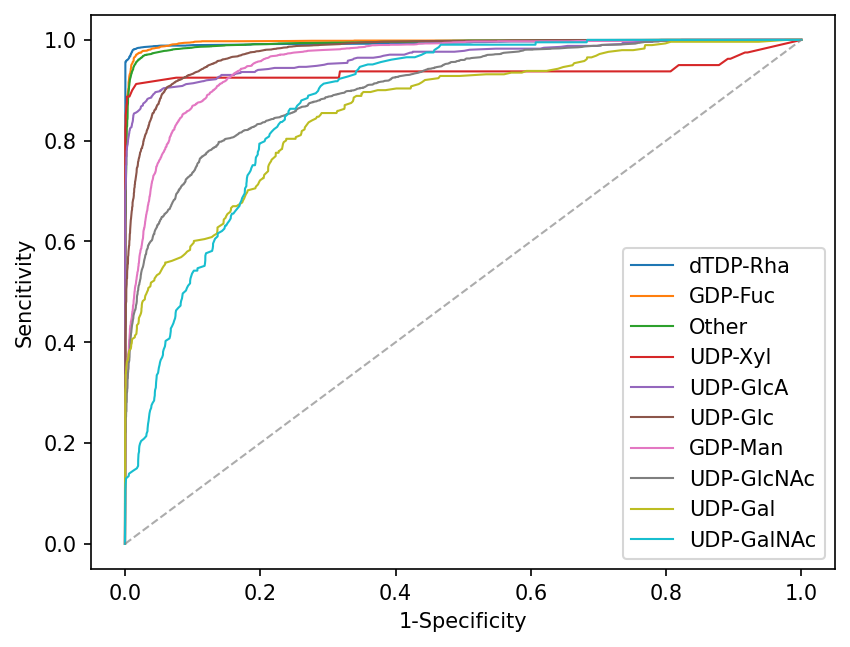

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import auc, roc_curve

fold_type = 'GTB'

if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_roc_history.npy"
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_roc_history.npy"
roc_history_dict = np.load(os.path.join('./result/', npy_filename), allow_pickle=True).item()

if fold_type == 'GTA':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6,
                        'dTDP-Rha': 7, 'Other': 8}
elif fold_type == 'GTB':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                        'dTDP-Rha': 8, 'Other': 9}
else:
    raise ValueError(f"Invalid family_fold_type: '{fold_type}'. Valid options are 'GTA' and 'GTB'.")
graph_label_dict = {v: k for k, v in graph_label_dict.items()}

plt.figure(dpi=150)
if fold_type == 'GTA':
    plot_flags = [7,1,4,0,3,6,2,8,5]
elif fold_type == 'GTB':
    plot_flags = [8,7,9,5,2,0,6,1,3,4]
for plot_flag in plot_flags:
    roc_history = roc_history_dict[plot_flag]
    auc_history, value, fpr, tpr = [], [], [], []
    for t_fpr, t_tpr, thre in roc_history:
        #计算AUC
        auc_score = auc(t_fpr, t_tpr)
        auc_history.append(auc_score)
        fpr.append([float(i) for i in t_fpr])
        value.extend([float(i) for i in t_fpr])
        tpr.append([float(i) for i in t_tpr])

    mean_fpr, min_fpr, max_fpr = [],[],[]
    mean_tpr, min_tpr, max_tpr= [],[],[]
    #这个是为了对曲线进行插值，因为每个曲线的样本不一样，所以获取到的fpr和tpr也不一样长度，
    #所以需要进行插值
    #插值的原理是，获取所有fpr的值，然后将每个交叉验证的roc都插值成和fpr的值一样多的长度。
    #插值并不会改变每个roc曲线的形状，这个可以放心使用
    unique = np.unique(np.array(value).flatten())
    #对fpr和tpr进行插值
    for l in range(len(fpr)):
        tpr[l] = np.interp(unique, fpr[l], tpr[l], 0, 1)
        fpr[l] = np.interp(unique, fpr[l], fpr[l], 0, 1)
        #将每个交叉验证的ROC都画出来
        # plt.plot(fpr[l], tpr[l])

    fpr = np.array(fpr)
    tpr = np.array(tpr)
    #求fpr和tpr的极大极小，获取每个实验所能触及的最大指标范围
    min_fpr = np.min(fpr, axis=0)
    max_fpr = np.max(fpr, axis=0)
    min_tpr = np.min(tpr, axis=0)
    max_tpr = np.max(tpr, axis=0)
    #获取均值，为了得到交叉验证的平均曲线
    mean_tpr = np.mean(tpr, axis=0)
    mean_fpr = np.mean(fpr, axis=0)
    mean_tpr[0] = 0

    
    # plt.title(graph_label_dict[plot_flag])
    plt.xlabel('1-Specificity')
    plt.ylabel('Sencitivity')
    #画平均曲线
    plt.plot(mean_fpr, mean_tpr, marker=None,
            linewidth=1,
            alpha=1, label=graph_label_dict[plot_flag])#markeredgecolor='b',
    
plt.plot(np.linspace(0, 1, 10), np.linspace(0, 1, 10), linestyle='--',c='grey', linewidth=1, alpha=0.65)

plt.legend(loc='lower right')
#展示图象
if fold_type == 'GTA':
    # output_path = f'./result/20251226-roc-GTA.png'
    # plt.savefig(output_path, dpi=1200)
    # output_path = f'./result/20251226-roc-GTA.svg'
    # plt.savefig(output_path, format='svg', dpi=1200)
    plt.show()
elif fold_type == 'GTB':
    # output_path = f'./result/20251226-roc-GTB.png'
    # plt.savefig(output_path, dpi=1200)
    # output_path = f'./result/20251226-roc-GTB.svg'
    # plt.savefig(output_path, format='svg', dpi=1200)
    plt.show()

    # break

## AUC-曲线下面积

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import auc, roc_curve

fold_type = 'GTB'

if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_roc_history.npy"
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_roc_history.npy"
roc_history_dict = np.load(os.path.join('./result/', npy_filename), allow_pickle=True).item()

if fold_type == 'GTA':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6,
                        'dTDP-Rha': 7, 'Other': 8}
elif fold_type == 'GTB':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                        'dTDP-Rha': 8, 'Other': 9}
else:
    raise ValueError(f"Invalid family_fold_type: '{fold_type}'. Valid options are 'GTA' and 'GTB'.")
graph_label_dict = {v: k for k, v in graph_label_dict.items()}

if fold_type == 'GTA':
    plot_flags = [7,1,4,0,3,6,2,8,5]
elif fold_type == 'GTB':
    plot_flags = [8,7,9,5,2,0,6,1,3,4]


# 假设 roc_history_dict 和 graph_label_dict 已经定义

for plot_flag in plot_flags:
    # 获取当前类别的ROC历史记录
    roc_history = roc_history_dict[plot_flag]
    
    auc_scores = []
    for t_fpr, t_tpr, thre in roc_history:
        # 计算AUC分数
        auc_score = auc(t_fpr, t_tpr)
        auc_scores.append(auc_score)
    
    # 计算并打印平均AUC值
    mean_auc = np.mean(auc_scores)
    print(f"Category {graph_label_dict[plot_flag]}: Mean AUC = {mean_auc:.4f}")

Category dTDP-Rha: Mean AUC = 0.9946
Category GDP-Fuc: Mean AUC = 0.9963
Category Other: Mean AUC = 0.9932
Category UDP-Xyl: Mean AUC = 0.9377
Category UDP-GlcA: Mean AUC = 0.9651
Category UDP-Glc: Mean AUC = 0.9766
Category GDP-Man: Mean AUC = 0.9561
Category UDP-GlcNAc: Mean AUC = 0.9051
Category UDP-Gal: Mean AUC = 0.8613
Category UDP-GalNAc: Mean AUC = 0.8725


## 计算准确率指标

In [15]:
import pandas as pd
import os

fold_type = 'GTB'
result_csv_folder = f'./model_param_alldata/'

if fold_type == 'GTA':
    best_epochs = {
        1: 367, 2: 764, 3: 631, 4: 570,
        5: 451, 6: 473, 7: 704, 8: 292,
        9: 364, 10: 353
    }
elif fold_type == 'GTB':
    best_epochs = {
        1: 206, 2: 245, 3: 152, 4: 141,
        5: 225, 6: 137, 7: 119, 8: 216,
        9: 205, 10: 143
    }

accuracy_results = {
    'UDP-Glc': [],
    'UDP-GlcNAc': []
}
for fold in range(1, 11):
    csv_folder = os.path.join(result_csv_folder, f'GTmining_6_6_{fold_type}_fold{fold}')
    csv_list = [x for x in os.listdir(csv_folder) if x.endswith('.csv') and 'validation_pred_labels_epoch' in x]
    csv_dict = {x.split('_')[4]: x for x in csv_list}
    try:
        df = pd.read_csv(os.path.join(csv_folder, csv_dict[str(best_epochs[fold])]))
    except Exception as e:
        print(f"Error reading CSV for fold {fold}: {e}")
        continue
    for l in ['UDP-Glc', 'UDP-GlcNAc']:
        df_fold_l = df.loc[df['Real_Label'] == l]
        accuracy = (df_fold_l['Predict_Label'] == df_fold_l['Real_Label']).mean()
        accuracy_results[l].append(accuracy)

# 计算每个类别的平均准确率
for l in accuracy_results:
    mean_accuracy = sum(accuracy_results[l]) / len(accuracy_results[l])
    print(f"Category {l}: Mean Accuracy = {mean_accuracy:.4f}")




Error reading CSV for fold 4: '141'
Category UDP-Glc: Mean Accuracy = 0.9792
Category UDP-GlcNAc: Mean Accuracy = 0.8002


In [10]:
df

,ID_Card,Real_Label,Predict_Label
0,GT20_AAQ76839_1,UDP-Glc,UDP-Glc
1,GT20_ABJ01243_1,UDP-Glc,UDP-Glc
2,GT20_ABX20921_1,UDP-Glc,UDP-Glc
3,GT20_ADE88919_1,UDP-Glc,UDP-Glc
4,GT20_ADN70927_1,UDP-Glc,UDP-Glc
...,...,...,...
3769,GT30_QEE36976_1,Other,UDP-GlcNAc
3770,GT30_QPN68872_1,Other,Other
3771,GT30_ABQ27390_1,Other,Other
3772,GT107_QPM90079_1,Other,Other


# 废物

## GTB的fold3好像加载不上来

In [1]:
import argparse
import os
import time
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.data import tu
from model.encoder import DiffPool
from sklearn.metrics import f1_score
import shutil
import argparse
import os
import random
import time

import dgl
import dgl.function as fn

import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
from dgl import DGLGraph
from dgl.data import tu
from model.encoder import DiffPool
from livelossplot import PlotLosses
from sklearn.metrics import f1_score
import shutil
import textwrap

import sys
# 获取命令行参数


/home/admin123/software/miniconda3/envs/GTmining_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import os
import pandas as pd

best_epochs = {}
fold_type = 'GTB'
family_fold_type = fold_type
log_save_folder = f'GTmining_6_6_{fold_type}_fold'
error_fold = 0
for fold in range(1, 11):
    if fold == 3:
        continue
    log_dir = f'./model_param_alldata/{log_save_folder}{fold}/validation_log.csv'
    df = pd.read_csv(log_dir, index_col=False)
    max_val_f1_score = df['validation_f1_score'].max()
    
    beat_epoch = df['epoch'].loc[df['validation_f1_score'] == max_val_f1_score].values[0]
    best_epochs[fold] = beat_epoch
    print(f"Fold type {fold_type}, Fold: {fold}, Max Val F1 Score: {max_val_f1_score}, Best Epoch: {beat_epoch}")

best_epochs[3] = 100

Fold type GTB, Fold: 1, Max Val F1 Score: 0.8913334586680826, Best Epoch: 483
Fold type GTB, Fold: 2, Max Val F1 Score: 0.7663228224239236, Best Epoch: 404
Fold type GTB, Fold: 4, Max Val F1 Score: 0.7684039384517768, Best Epoch: 483
Fold type GTB, Fold: 5, Max Val F1 Score: 0.8018020886744562, Best Epoch: 428
Fold type GTB, Fold: 6, Max Val F1 Score: 0.7950383478817663, Best Epoch: 427
Fold type GTB, Fold: 7, Max Val F1 Score: 0.7079288659362848, Best Epoch: 393
Fold type GTB, Fold: 8, Max Val F1 Score: 0.6974633264704687, Best Epoch: 302
Fold type GTB, Fold: 9, Max Val F1 Score: 0.7810649361245214, Best Epoch: 345
Fold type GTB, Fold: 10, Max Val F1 Score: 0.7861377751822867, Best Epoch: 315


In [7]:
def prepare_data(dataset, shuffle=False, prog_args=None):
    """
    preprocess TU dataset according to DiffPool's paper setting and load dataset into dataloader
    """
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )



In [16]:
fold_num = 3

param_folder = f'{log_save_folder}{fold}'
print("{:=^100}".format('prog_args'))
# 尝试
prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                            batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                            dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                            load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)
print(textwrap.fill(str(prog_args), width=100))




print("{:=^100}".format('加载数据'))
dataset_train = tu.LegacyTUDataset(name="GTmining",
                                    raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/train/')
dataset_validation = tu.LegacyTUDataset(name="GTmining",
                                   raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/')
dataset_test = tu.LegacyTUDataset(name="GTmining",
                                   raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/test/')
train_dataloader = prepare_data(dataset_train, shuffle=True, prog_args=prog_args)
validation_dataloader = prepare_data(dataset_validation, shuffle=False, prog_args=prog_args)
test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)


input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
input_dim_validation, label_dim_validation, max_num_node_validation = dataset_validation.statistics()
input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
max_num_node = max([max_num_node_train, max_num_node_validation, max_num_node_test])
input_dim = input_dim_train
label_dim = label_dim_train
print("++++++++++ STATISTICS ABOUT THE DATASET ++++++++++")
print("dataset feature dimension is", input_dim_train)
print("dataset label dimension is", label_dim_train)
print("the max num node is", max_num_node)
print("number of graphs is", len(dataset_train) + len(dataset_validation)+ len(dataset_test))

hidden_dim = prog_args.hidden_dim  # used to be 64
embedding_dim = prog_args.embedding_dim

assign_dim = int(max_num_node * prog_args.pool_ratio)
print("++++++++++MODEL STATISTICS++++++++")
print("model hidden dim is", hidden_dim)
print("model embedding dim for graph instance embedding", embedding_dim)
print("initial batched pool graph dim is", assign_dim)

activation = F.relu

if family_fold_type == 'GTA':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6,
                        'dTDP-Rha': 7, 'Other': 8}
elif family_fold_type == 'GTB':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                        'dTDP-Rha': 8, 'Other': 9}
else:
    raise ValueError(f"Invalid family_fold_type: '{prog_args.family_fold_type}'. Valid options are 'GTA' and 'GTB'.")

df_cluster = pd.read_excel(f'../data/cluster/{family_fold_type}/dataseat_split_{fold_num}.xlsx')
df_cluster = df_cluster.loc[df_cluster['Dataset']=='train']
df_cluster.reset_index(drop=True, inplace=True)
custom_loss_weight = []
total_sample = df_cluster.shape[0]
for x in graph_label_dict.keys():
    df_x = df_cluster.loc[df_cluster['Activate']==x]
    df_x.reset_index(drop=True, inplace=True)
    x_sample = df_x.shape[0]
    custom_loss_weight.append(total_sample/x_sample)

assert len(custom_loss_weight) == label_dim_train, 'Wrong custom loss weight, please check what happen.'

# initialize model
model = DiffPool(
    input_dim,
    hidden_dim,
    embedding_dim,
    label_dim,
    activation,
    prog_args.gc_per_block,
    prog_args.dropout,
    prog_args.num_pool,
    prog_args.linkpred,
    prog_args.batch_size,
    prog_args.aggregator_type,
    assign_dim,
    prog_args.pool_ratio,
    custom_loss_weight
)
print("model init finished")
print("MODEL:::::::", prog_args.method)
if prog_args.cuda:
    model = model.cuda()

# 先过一遍train_dataloader，让模型中的一些参数先初始化一下
model.train()
for batch_idx, (batch_graph, graph_labels) in enumerate(train_dataloader):
    for key, value in batch_graph.ndata.items():
        batch_graph.ndata[key] = value.float()
    graph_labels = graph_labels.long()
    if torch.cuda.is_available():
        batch_graph = batch_graph.to(torch.cuda.current_device())
        graph_labels = graph_labels.cuda()
    ypred = model(batch_graph)
    loss = model.loss(ypred, graph_labels)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=prog_args.clip)
    model.zero_grad()

epoch = best_epochs[fold_num]

begin_time = time.time()
print("\nEPOCH ###### {} ######".format(epoch))
if epoch is not None and prog_args.save_dir is not None:
    model.load_state_dict(
        torch.load(
            prog_args.save_dir
            + "/"
            + prog_args.dataset
            + "/model.iter-"
            + "{:04d}".format(epoch), weights_only=True
        )
    )




=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTB_fold3', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type='GTB')
================================================加载数据================================================
++++++++++ STATISTICS ABOUT THE DATASET ++++++++++
dataset feature dimension is 7
dataset label dimension is 10
the max num node is 655
number of graphs is 19896
++++++++++MODEL STATISTICS++++++++
model hidden dim is 64
model embedding dim for graph instance embedding 64
initial batched pool graph dim is 65
model init finished
MODEL::::::: diffpool

EPOCH ###### 100 ######
